In [1]:
import numpy as np
import base
import matrix
import matplotlib.pyplot as plt

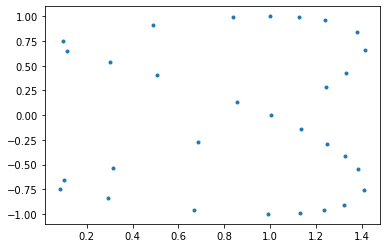

In [2]:
# Random example
t = np.arange(30)
x = np.abs(np.cos(np.arange(30))-np.sin(np.arange(30)))
y = (np.cos(np.arange(30)))
plt.plot(x,y,marker='.' ,linestyle='')
plt.show()

In [3]:
D = np.zeros((30,30))
for i in range(len(x)):
    for j in range(len(y)):
        D[i,j] = np.sqrt((x[i]-x[j])**2+ (y[i]-y[j])**2)  

In [4]:
s = base.traveling_MC_constDist(t,D,100000)[0]
min_dist = base.traveling_MC_constDist(t,D,100000)[1]


C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


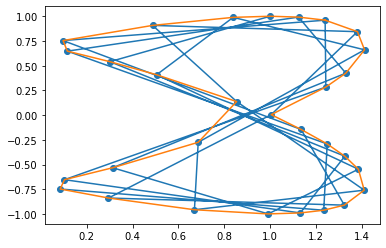

In [5]:
x_sort = x[s]
y_sort = y[s]
X = np.append(x_sort,x_sort[0])
Y = np.append(y_sort,y_sort[0])

plt.scatter(x,y)
plt.plot(x,y)
plt.plot(X,Y)

In [6]:
print(min_dist[-1])

6.939766978067631


# Test of different temperatures $\alpha =1$

In [7]:
z = 0
for x in range(len(D)):
    z = z+ max(D[x])
print(z)
# => T start = 10*z everything is accepted

54.87268077950246


In [8]:
tries = 10000
T = np.logspace( 3, -6, num=10, base=10 )
step = np.arange(tries+1)


In [9]:
d_temp = {}
for x in range(len(T)):
    d_temp["{0}".format(T[x])] = base.traveling_MC_constDist(t,D,10000,starting_temp=T[x],alpha=1)


C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [10]:
keys= ['1000.0', '100.0', '10.0', '1.0', '0.1', '0.01', '0.001', '0.0001', '1e-05', '1e-06']


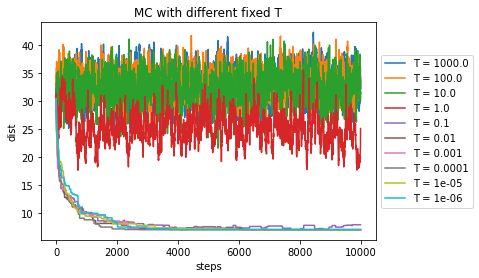

In [11]:
for k in range(len(keys)):
    plt.plot(step,d_temp[keys[k]][1],label =f'T = {keys[k]}')
    plt.ylabel('dist')
    plt.xlabel('steps')
    plt.title('MC with different fixed T')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

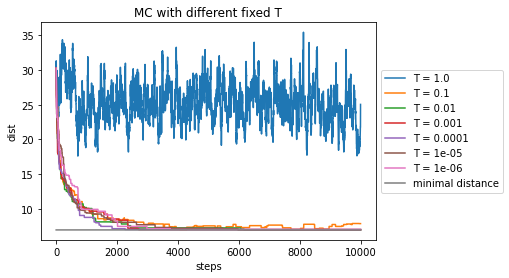

In [12]:
for k in range(3,len(keys)):
    plt.plot(step,d_temp[keys[k]][1],label =f'T = {keys[k]}')
    plt.ylabel('dist')
    plt.xlabel('steps')
    plt.title('MC with different fixed T')
plt.plot(step,np.ones(len(step))*min_dist[-1], label ='minimal distance')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

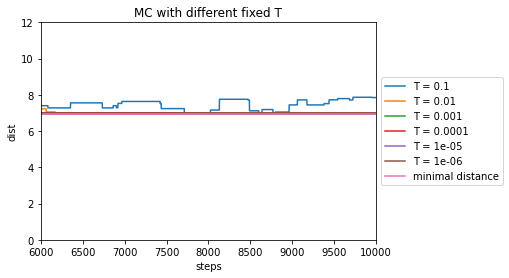

In [13]:
for k in range(4,len(keys)):
    plt.plot(step,d_temp[keys[k]][1],label =f'T = {keys[k]}')
    plt.ylabel('dist')
    plt.xlabel('steps')
    plt.title('MC with different fixed T')
plt.plot(step,np.ones(len(step))*min_dist[-1], label ='minimal distance')
plt.xlim(6000,10000)
plt.ylim(0,12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

 Need T < 1 to get significant change and reach minimal distance after 10000 steps
 Now to test values between 1 and 0 by 0.05 steps.

In [14]:
T2 = np.round(np.linspace(1,0,21),decimals=2)
d_temp2 = {}
for x in range(len(T2)):
    d_temp2["{0}".format(T2[x])] = base.traveling_MC_constDist(t,D,10000,starting_temp=T2[x],alpha=1)
print(d_temp2.keys())

C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: divide by zero encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: invalid value encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


dict_keys(['1.0', '0.95', '0.9', '0.85', '0.8', '0.75', '0.7', '0.65', '0.6', '0.55', '0.5', '0.45', '0.4', '0.35', '0.3', '0.25', '0.2', '0.15', '0.1', '0.05', '0.0'])


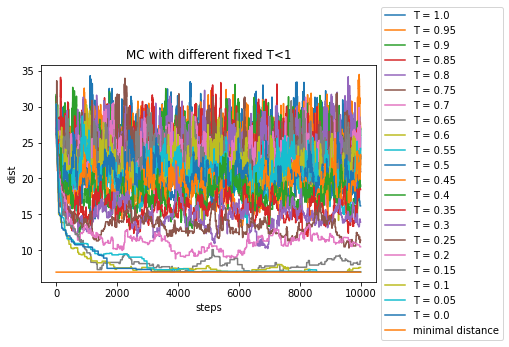

In [15]:
keys2 =['1.0', '0.95', '0.9', '0.85', '0.8', '0.75', '0.7', '0.65', '0.6', '0.55', '0.5', '0.45', '0.4', '0.35', '0.3', '0.25', '0.2', '0.15', '0.1', '0.05','0.0']
for k in range(len(keys2)):
    plt.plot(step,d_temp2[keys2[k]][1],label =f'T = {keys2[k]}')
    plt.ylabel('dist')
    plt.xlabel('steps')
    plt.title('MC with different fixed T<1')
plt.plot(step,np.ones(len(step))*min_dist[-1], label ='minimal distance')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

This makes sense, that the smaller T, the smaller the possibility to accept a higher distance via the uniform distribution since: 
$ \exp((d_\text{old}-d_\text{new})/T) \underrightarrow{T \rightarrow 0}
  \left\{
\begin{array}{lll}
\infty & d_\text{old} > d_\text{new} \\
1 & d_\text{old} = d_\text{new} \\
-\infty & \, \textrm{else} \\
\end{array}
\right. $

which only accepts changes  if $d_\text{old} < d_\text{new}$ for small $T$

# Test of different $\alpha$ with $T_\text{start} = 550$ 
$T_\text{start} = 550 = 10 \cdot$ max(dist)

In [31]:
alp = np.round(np.linspace(1,0,21),decimals=2)
d_alp = {}
for x in range(len(alp)):
    d_alp["{0}".format(alp[x])] = base.traveling_MC_constDist(t,D,20000,starting_temp=550,alpha=alp[x])


C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: overflow encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: divide by zero encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: invalid value encountered in scalar divide
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [32]:
step =np.arange(20001)

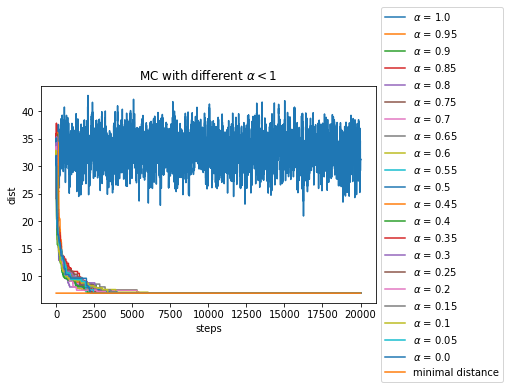

In [33]:
for k in range(len(keys2)):
    plt.plot(step,d_alp[keys2[k]][1],label =fr'$\alpha$ = {keys2[k]}')
    plt.ylabel('dist')
    plt.xlabel('steps')
    plt.title(rf'MC with different $\alpha<1$')
plt.plot(step,np.ones(len(step))*min_dist[-1], label ='minimal distance')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

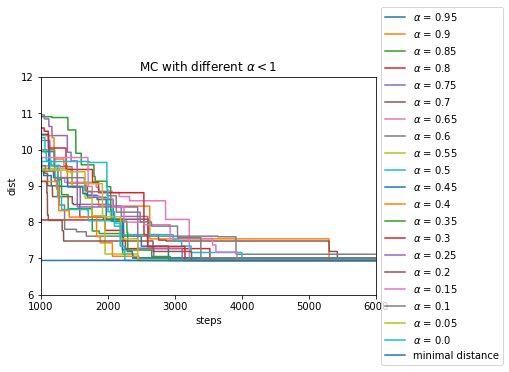

In [34]:
for k in range(1,len(keys2)):
    plt.plot(step,d_alp[keys2[k]][1],label =fr'$\alpha$ = {keys2[k]}')
    plt.ylabel('dist')
    plt.xlabel('steps')
    plt.title(rf'MC with different $\alpha<1$')
plt.plot(step,np.ones(len(step))*min_dist[-1], label ='minimal distance')
plt.xlim(1000,6000)
plt.ylim(6,12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

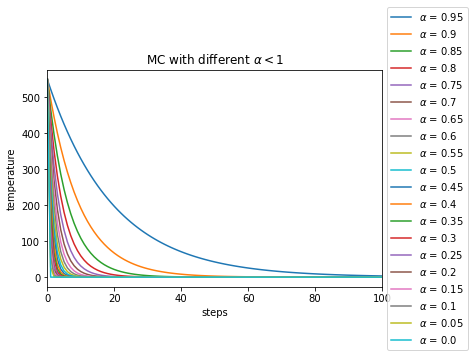

In [35]:
for k in range(1,len(keys2)):
    plt.plot(step,d_alp[keys2[k]][2],label =fr'$\alpha$ = {keys2[k]}')
    plt.ylabel('temperature')
    plt.xlabel('steps')
    plt.title(rf'MC with different $\alpha<1$')
    plt.xlim(0,100)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

For $ \alpha < 0.8$ the algorithm behaves like the algorithm with starting temperature $T=0$ after less than 20 steps. The higher $\alpha$ the higher $T$ stays and we accept new starting variations more easily

# Random Matrix  test T & alpha

In [47]:
def random_dist_matrix(N,low,high,save='0'):
    x = np.random.uniform(low, high =high,size=N)
    y = np.random.uniform(low, high =high,size=N)
    D = np.zeros((N,N))
    for i in range(len(x)):
        for j in range(len(y)):
            D[i,j] = np.sqrt((x[i]-x[j])**2+ (y[i]-y[j])**2)
    with open('testmatrix_rand('+str(low)+'_'+str(high)+')_N'+str(N)+'_t'+'_'+str(save)+'.txt', 'w') as outfile:

        outfile.write('# Array shape: {0}\n'.format(D.shape))

        for data_slice in D:

                np.savetxt(outfile, data_slice, fmt='%-7.2f')


                # Writing out a break to indicate different slices...
                outfile.write('# New slice\n')
    return D,x,y

In [48]:
D,x,y=random_dist_matrix(60,0,10)

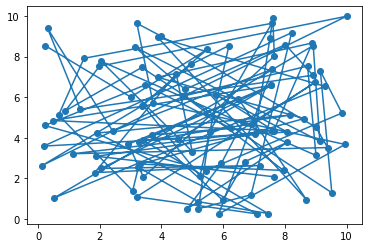

In [51]:
t = np.arange(100)
plt.scatter(x,y)
plt.plot(x,y)

In [68]:
tries = 80000
steps = np.arange(tries+1)
s1,d1 = base.traveling_MC_constDist(t,D,tries)[0:2]
s2,d2 = base.traveling_MC_constDist(t,D,tries)[0:2]
s3,d3 = base.traveling_MC_constDist(t,D,tries)[0:2]
s4,d4 = base.traveling_MC_constDist(t,D,tries)[0:2]
s5,d5 = base.traveling_MC_constDist(t,D,tries)[0:2]
s6,d6 = base.traveling_MC_constDist(t,D,tries)[0:2]

C:\Users\Win10\Computational physics\Projects\base.py:118: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [72]:
print(d1[-1],d2[-1],d3[-1],d4[-1],d5[-1],d6[-1])

85.60455412501204 83.23894203847256 85.2946881430706 89.64194324598017 83.33665742508764 86.30120395449606


(80.0, 100.0)

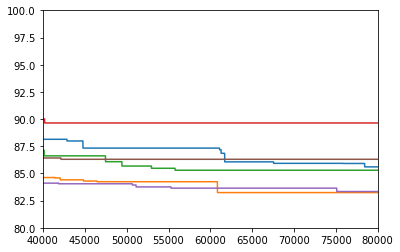

In [70]:
plt.plot(steps,d1)
plt.plot(steps,d2)
plt.plot(steps,d3)
plt.plot(steps,d4)
plt.plot(steps,d5)
plt.plot(steps,d6)
plt.xlim(40000,80000)
plt.ylim(80,100)

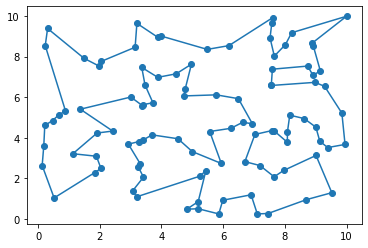

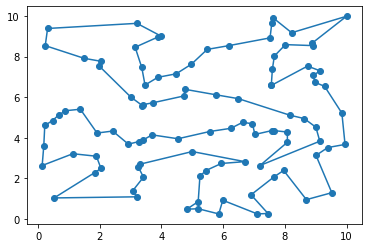

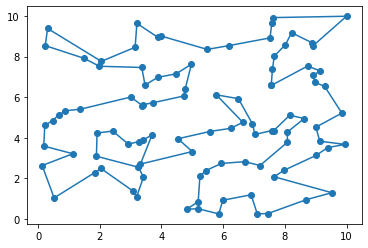

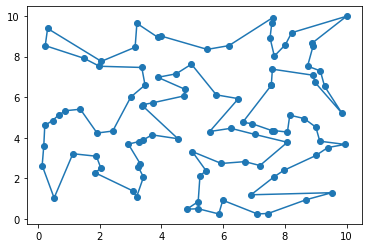

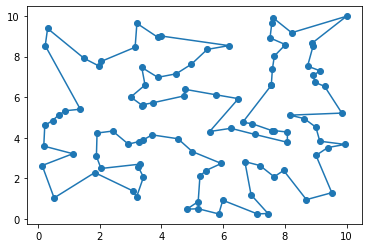

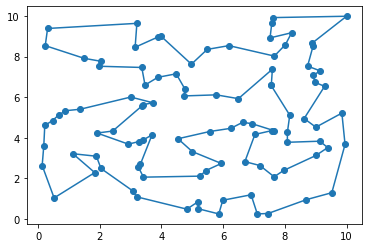

In [71]:
collection = [s1,s2,s3,s4,s5,s6]
for col in range(len(collection)):
    c = collection[col]
    x_sort = x[c]
    y_sort = y[c]
    X = np.append(x_sort,x_sort[0])
    Y = np.append(y_sort,y_sort[0])
    plt.scatter(x,y)
    plt.plot(X,Y)
    plt.show()